<a href="https://colab.research.google.com/github/anushreejothi-lang/CodeAlpha_HandwrittenCharacterRecognition/blob/main/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


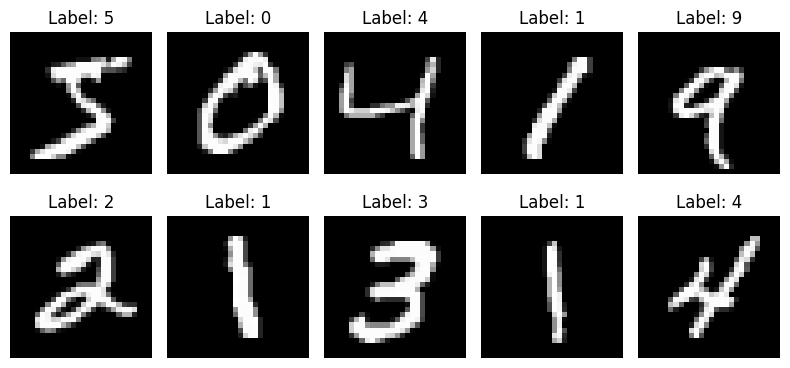


Step 1 & 2 done: Libraries set up, MNIST loaded, sample images visualized.


In [ ]:
# CodeAlpha - Task 3: Handwritten Character Recognition
# STEP 1: Setup + STEP 2: Load Dataset

# ---- Install these first (run in terminal / Colab cell) ----
# pip install tensorflow numpy matplotlib opencv-python scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# ---- Load MNIST dataset (60,000 train + 10,000 test handwritten digit images) ----
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)   # (60000, 28, 28)
print("Training labels shape:", y_train.shape) # (60000,)
print("Test data shape:", X_test.shape)        # (10000, 28, 28)
print("Test labels shape:", y_test.shape)      # (10000,)

# ---- Visualize a few sample digits ----
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig("sample_digits.png")
plt.show()

print("\nStep 1 & 2 done: Libraries set up, MNIST loaded, sample images visualized.")

In [ ]:
# STEP 3: Preprocess Data

from tensorflow.keras.utils import to_categorical

# ---- Normalize pixel values (0-255 -> 0-1) ----
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# ---- Reshape to (28, 28, 1) since CNN expects a channel dimension ----
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# ---- One-hot encode labels (5 -> [0,0,0,0,0,1,0,0,0,0]) ----
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("X_train shape after reshape:", X_train.shape)   # (60000, 28, 28, 1)
print("X_test shape after reshape:", X_test.shape)      # (10000, 28, 28, 1)
print("y_train_cat shape:", y_train_cat.shape)           # (60000, 10)
print("Sample label before encoding:", y_train[0])
print("Sample label after encoding:", y_train_cat[0])

print("\nStep 3 done: Data normalized, reshaped, and labels one-hot encoded.")

X_train shape after reshape: (60000, 28, 28, 1)
X_test shape after reshape: (10000, 28, 28, 1)
y_train_cat shape: (60000, 10)
Sample label before encoding: 5
Sample label after encoding: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

Step 3 done: Data normalized, reshaped, and labels one-hot encoded.


In [ ]:
# STEP 4: Build the CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # 1st Convolution block
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    # 2nd Convolution block
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten + Fully Connected layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),          # helps prevent overfitting
    Dense(10, activation='softmax')   # 10 output classes (digits 0-9)
])

# ---- Print model architecture summary ----
model.summary()

print("\nStep 4 done: CNN model built.")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Step 4 done: CNN model built.


In [ ]:
# STEP 5: Compile & Train the Model

# ---- Compile the model ----
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---- Train the model ----
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=128,
    verbose=1
)

print("\nStep 5 done: Model trained for 10 epochs.")

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 127ms/step - accuracy: 0.9247 - loss: 0.2484 - val_accuracy: 0.9777 - val_loss: 0.0696
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 120ms/step - accuracy: 0.9779 - loss: 0.0726 - val_accuracy: 0.9873 - val_loss: 0.0425
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 120ms/step - accuracy: 0.9834 - loss: 0.0532 - val_accuracy: 0.9905 - val_loss: 0.0303
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 120ms/step - accuracy: 0.9870 - loss: 0.0419 - val_accuracy: 0.9904 - val_loss: 0.0275
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 122ms/step - accuracy: 0.9899 - loss: 0.0328 - val_accuracy: 0.9907 - val_loss: 0.0257
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 118ms/step - accuracy: 0.9908 - loss: 0.0277 - val_accuracy: 0.9913 - val_loss: 0.0243
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 122ms/step - accuracy: 0.9930 - loss: 0.0236 - val_accuracy: 0.9917 - val_loss: 0.0245
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 121ms/step - accuracy: 0.9930 - loss: 0

Final Test Accuracy: 99.23%
Final Test Loss: 0.0243


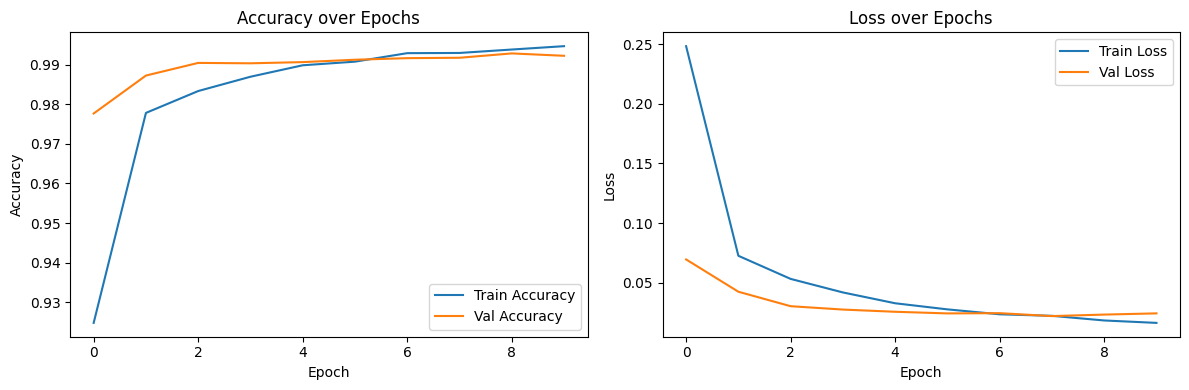

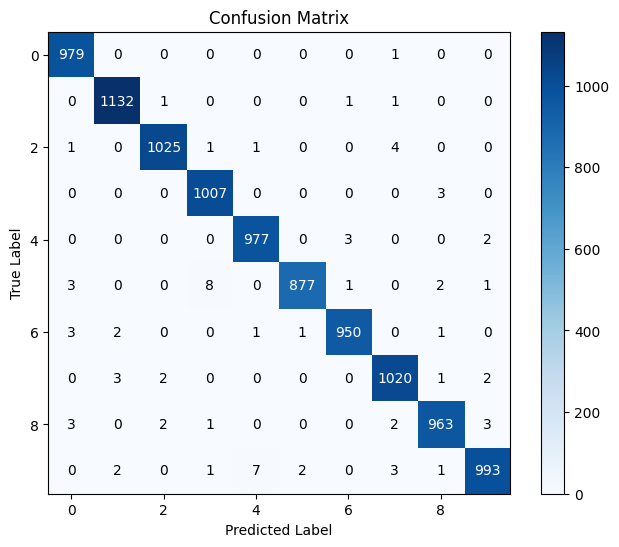

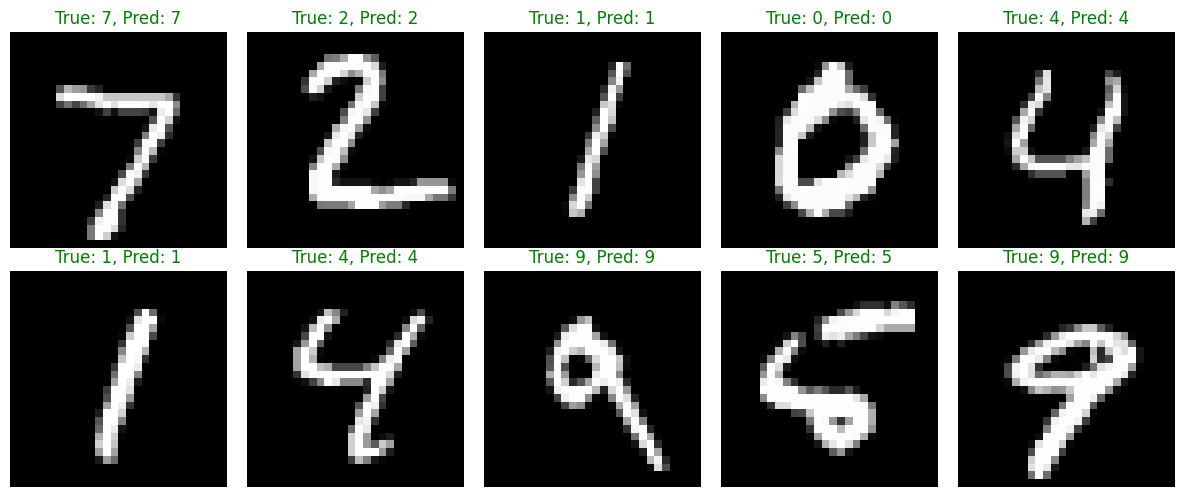


Step 6 done: Model evaluated, confusion matrix + predictions visualized.


In [ ]:
# STEP 6: Evaluate the Model

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# ---- Final test accuracy ----
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

# ---- Plot training vs validation accuracy/loss ----
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

# ---- Predictions on test set ----
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# ---- Confusion Matrix ----
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.savefig("confusion_matrix.png")
plt.show()

# ---- Show sample predictions (correct + wrong) ----
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if y_pred_classes[i] == y_true_classes[i] else 'red'
    plt.title(f"True: {y_true_classes[i]}, Pred: {y_pred_classes[i]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.savefig("sample_predictions.png")
plt.show()

print("\nStep 6 done: Model evaluated, confusion matrix + predictions visualized.")

Upload a photo of your handwritten digit (single digit, 0-9):


Saving WhatsApp Image 2026-09-13 at 1.49.58 PM.jpeg to WhatsApp Image 2026-09-13 at 1.49.58 PM.jpeg


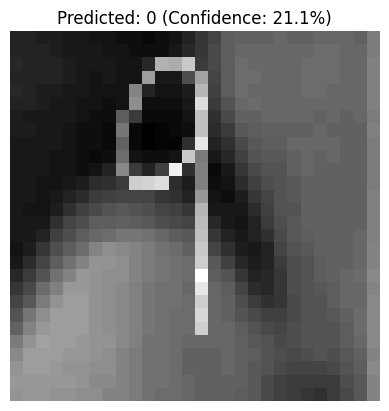


Model Prediction: 0
Confidence: 21.12%

Step 7 done: Tested model on a real handwritten digit.


In [ ]:
# STEP 7: Test with Your Own Handwritten Digit

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ---- Upload your own handwritten digit image ----
# Tip: Write a single digit (0-9) with a THICK black pen on plain WHITE paper,
# take a clear photo, crop tightly around just the digit, then upload it below.
print("Upload a photo of your handwritten digit (single digit, 0-9):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# ---- Read and preprocess the image ----
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Invert if background is white (MNIST expects white digit on black background)
if np.mean(img) > 127:
    img = cv2.bitwise_not(img)

# Resize to 28x28 (MNIST size)
img = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)

# Normalize and reshape for the model
img_input = img.astype('float32') / 255.0
img_input = img_input.reshape(1, 28, 28, 1)

# ---- Predict ----
prediction = model.predict(img_input, verbose=0)
predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100

# ---- Show result ----
plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {predicted_digit} (Confidence: {confidence:.1f}%)")
plt.axis('off')
plt.savefig("my_digit_prediction.png")
plt.show()

print(f"\nModel Prediction: {predicted_digit}")
print(f"Confidence: {confidence:.2f}%")
print("\nStep 7 done: Tested model on a real handwritten digit.")

Upload a photo of your handwritten digit (single digit, 0-9):


Saving WhatsApp Image 2026-09-13 at 1.49.58 PM.jpeg to WhatsApp Image 2026-09-13 at 1.49.58 PM (1).jpeg


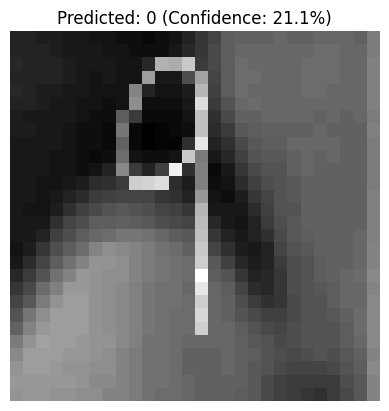


Model Prediction: 0
Confidence: 21.12%

Step 7 done: Tested model on a real handwritten digit.


In [ ]:
# STEP 7: Test with Your Own Handwritten Digit

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ---- Upload your own handwritten digit image ----
# Tip: Write a single digit (0-9) with a THICK black pen on plain WHITE paper,
# take a clear photo, crop tightly around just the digit, then upload it below.
print("Upload a photo of your handwritten digit (single digit, 0-9):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# ---- Read and preprocess the image ----
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Invert if background is white (MNIST expects white digit on black background)
if np.mean(img) > 127:
    img = cv2.bitwise_not(img)

# Resize to 28x28 (MNIST size)
img = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)

# Normalize and reshape for the model
img_input = img.astype('float32') / 255.0
img_input = img_input.reshape(1, 28, 28, 1)

# ---- Predict ----
prediction = model.predict(img_input, verbose=0)
predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100

# ---- Show result ----
plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {predicted_digit} (Confidence: {confidence:.1f}%)")
plt.axis('off')
plt.savefig("my_digit_prediction.png")
plt.show()

print(f"\nModel Prediction: {predicted_digit}")
print(f"Confidence: {confidence:.2f}%")
print("\nStep 7 done: Tested model on a real handwritten digit.")

Upload a photo of your handwritten digit (single digit, 0-9):


Saving WhatsApp Image 2026-09-13 at 1.49.58 PM.jpeg to WhatsApp Image 2026-09-13 at 1.49.58 PM (2).jpeg
Top 3 predictions:
  Digit 7: 33.17%
  Digit 2: 18.81%
  Digit 1: 13.71%


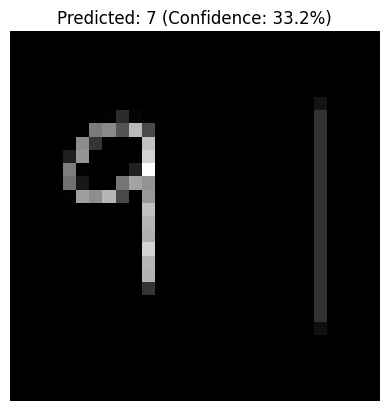


Final Prediction: 7
Confidence: 33.17%

Step 7 done (improved preprocessing).


In [8]:
# STEP 7 (IMPROVED): Test with Your Own Handwritten Digit
# Better preprocessing: thresholding, cropping to digit, centering, thickening

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Upload a photo of your handwritten digit (single digit, 0-9):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# ---- Read image in grayscale ----
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# ---- Blur slightly to reduce noise/shadows ----
img = cv2.GaussianBlur(img, (5, 5), 0)

# ---- Use OTSU thresholding to get a clean binary image (handles shadows/gray bg) ----
_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ---- Ensure digit is WHITE on BLACK background (MNIST style) ----
if np.mean(thresh) > 127:
    thresh = cv2.bitwise_not(thresh)

# ---- Find the digit's bounding box and crop tightly around it ----
coords = cv2.findNonZero(thresh)
x, y, w, h = cv2.boundingRect(coords)
digit = thresh[y:y+h, x:x+w]

# ---- Make it square by padding (so digit doesn't get stretched/distorted) ----
size = max(w, h)
square = np.zeros((size, size), dtype=np.uint8)
x_offset = (size - w) // 2
y_offset = (size - h) // 2
square[y_offset:y_offset+h, x_offset:x_offset+w] = digit

# ---- Add padding around the digit (MNIST digits have margin, not edge-to-edge) ----
pad = size // 4
padded = cv2.copyMakeBorder(square, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=0)

# ---- Thicken the strokes slightly (helps thin pen lines look like MNIST strokes) ----
kernel = np.ones((3, 3), np.uint8)
padded = cv2.dilate(padded, kernel, iterations=1)

# ---- Resize to 28x28 ----
final_img = cv2.resize(padded, (28, 28), interpolation=cv2.INTER_AREA)

# ---- Normalize and reshape for model ----
img_input = final_img.astype('float32') / 255.0
img_input = img_input.reshape(1, 28, 28, 1)

# ---- Predict ----
prediction = model.predict(img_input, verbose=0)
predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100

# ---- Show top-3 predictions ----
top3 = np.argsort(prediction[0])[-3:][::-1]
print("Top 3 predictions:")
for digit_class in top3:
    print(f"  Digit {digit_class}: {prediction[0][digit_class]*100:.2f}%")

# ---- Display result ----
plt.imshow(final_img, cmap='gray')
plt.title(f"Predicted: {predicted_digit} (Confidence: {confidence:.1f}%)")
plt.axis('off')
plt.savefig("my_digit_prediction_v2.png")
plt.show()

print(f"\nFinal Prediction: {predicted_digit}")
print(f"Confidence: {confidence:.2f}%")
print("\nStep 7 done (improved preprocessing).")

Upload a photo of your handwritten digit (single digit, 0-9):


Saving WhatsApp Image 2026-09-13 at 1.49.58 PM.jpeg to WhatsApp Image 2026-09-13 at 1.49.58 PM (3).jpeg
Top 3 predictions:
  Digit 9: 43.46%
  Digit 4: 17.56%
  Digit 3: 16.99%


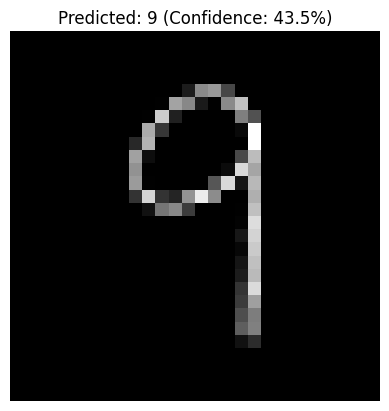


Final Prediction: 9
Confidence: 43.46%

Step 7 done (v3 - largest contour fix).


In [9]:
# STEP 7 (V3 - FIXED): Test with Your Own Handwritten Digit
# Uses largest contour only (ignores shadows/noise/paper edges)

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Upload a photo of your handwritten digit (single digit, 0-9):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# ---- Read image in grayscale ----
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# ---- Blur to reduce noise ----
img = cv2.GaussianBlur(img, (5, 5), 0)

# ---- OTSU thresholding ----
_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Ensure white digit on black background
if np.mean(thresh) > 127:
    thresh = cv2.bitwise_not(thresh)

# ---- Remove small noise specks with morphological opening ----
kernel_clean = np.ones((3, 3), np.uint8)
cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_clean)

# ---- Find ALL contours, then pick the LARGEST one (this is the actual digit) ----
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if len(contours) == 0:
    print("No digit detected! Try a clearer photo with better contrast.")
else:
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    # ---- Crop tightly to just the digit ----
    digit = thresh[y:y+h, x:x+w]

    # ---- Make square with padding (preserve aspect ratio) ----
    size = max(w, h)
    square = np.zeros((size, size), dtype=np.uint8)
    x_offset = (size - w) // 2
    y_offset = (size - h) // 2
    square[y_offset:y_offset+h, x_offset:x_offset+w] = digit

    # ---- Add margin around digit (MNIST style) ----
    pad = size // 4
    padded = cv2.copyMakeBorder(square, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=0)

    # ---- Slightly thicken strokes ----
    kernel = np.ones((3, 3), np.uint8)
    padded = cv2.dilate(padded, kernel, iterations=1)

    # ---- Resize to 28x28 ----
    final_img = cv2.resize(padded, (28, 28), interpolation=cv2.INTER_AREA)

    # ---- Predict ----
    img_input = final_img.astype('float32') / 255.0
    img_input = img_input.reshape(1, 28, 28, 1)
    prediction = model.predict(img_input, verbose=0)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    top3 = np.argsort(prediction[0])[-3:][::-1]
    print("Top 3 predictions:")
    for digit_class in top3:
        print(f"  Digit {digit_class}: {prediction[0][digit_class]*100:.2f}%")

    plt.imshow(final_img, cmap='gray')
    plt.title(f"Predicted: {predicted_digit} (Confidence: {confidence:.1f}%)")
    plt.axis('off')
    plt.savefig("my_digit_prediction_v3.png")
    plt.show()

    print(f"\nFinal Prediction: {predicted_digit}")
    print(f"Confidence: {confidence:.2f}%")
    print("\nStep 7 done (v3 - largest contour fix).")